## Business Understanding

We want to classify train stations based on how vulnerable they are to meteorological phenomena in Finland. Our goal is to cluster train stations by the amount of delay associated with a weather phenomena. Even though the study is done for educational purposes, the results could be used by VR, for example in prioritizing winter maintenance resources by station. The assumption is that weather causes delays and that some stations are more prone to delays caused or associated different weather phenomena such as rain or freezing temperatures. Only stations where a train has actually stopped are used. The plan is to first extract the data from Kaggle, understand the data, prepare the data, model and evaluate.

### Research questions

- Is there a clear difference between stations in how much weather phenomena increases train delays?
- Are weather-prone stations geographically distinct?

---

## Data Understanding

The data is pulled from Kaggle using Python. The data consists of Finnish railway operational data paired with meteorological observations for delay prediction. The data is filled with records containing a single timetable event `Arrival / Departure` of long-distance VR-trains at stations as well as the weather observation from the nearest weather station at the time of the stop.

[Link to Data (www.kaggle.com)](https://www.kaggle.com/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw)

Period: 2018–2025 | Records: ~48 million | Columns: up to 125 | Sources: Digitraffic + Finnish Meteorological Institute

> **Note:** All exploration below is based on a single month of data. This sample is used only to understand the data's structure and quality and the full date range will be used for modeling.

In [1]:
import kagglehub
import pandas as pd

#download the dataset from Kaggle using the kagglehub library
path = kagglehub.dataset_download("viniborin/finland-integrated-train-weather-dataset-fi-tw")

/Users/blendigraicevci/Documents/dkkog2/dkko-g2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

#import the dataset
file = Path(path) / "matched_data_flat_2025_10.parquet"
metadata_file = Path(path) / "metadata_train_stations.csv"

print(path)

#read the parquet file into a pandas dataframe
df = pd.read_parquet(file)

#List the available columns in the dataset
for i, (col, dtype) in enumerate(zip(df.columns, df.dtypes), 1):
    print(f"{i:>3}. {col:<45} {dtype}")

/Users/blendigraicevci/.cache/kagglehub/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw/versions/3
  1. trainNumber                                   int64
  2. departureDate                                 str
  3. operatorUICCode                               int64
  4. operatorShortCode                             str
  5. trainType                                     str
  6. trainCategory                                 str
  7. commuterLineID                                float64
  8. runningCurrently                              bool
  9. cancelled                                     bool
 10. version                                       int64
 11. timetableType                                 str
 12. timetableAcceptanceDate                       str
 13. stationName                                   str
 14. stationShortCode                              str
 15. stationUICCode                                int64
 16. countryCode                            

In total we have 123 columns of data in this dataset. We have all the necessary features to correctly associate station delays with weather phenomena. We have different weather data for the time of the stop and also rolling-window aggregates 12h/24h/72h from the time of the stop. We will be using only the instantaneous weather observations for this study. In addition we have necessary information for training such as the delayed time, causes for delay, station data and train data. The next step is to extract and prepare only the necessary data needed to train the model.

In [3]:
df.describe(include='all')

,trainNumber,departureDate,operatorUICCode,operatorShortCode,trainType,trainCategory,commuterLineID,runningCurrently,cancelled,version,...,Precipitation amount (12h mean),Precipitation amount (12h cumulative),Precipitation amount (24h mean),Precipitation amount (24h cumulative),Precipitation amount (72h mean),Precipitation amount (72h cumulative),estimateSource,liveEstimateTime,unknownDelay,unknownTrack
count,537724.000000,537724,537724.000000,537724,537724,537724,0.0,537724,537724,5.377240e+05,...,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,537724.000000,31276,31253,6687,390
unique,NaN,31,NaN,6,8,1,NaN,2,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2,20886,2,2
top,NaN,2025-10-17,NaN,vr,IC,Long-distance,NaN,False,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,LIIKE_AUTOMATIC,2025-10-03T18:17:00.000Z,False,True
freq,NaN,19226,NaN,536846,367444,537724,NaN,537540,536382,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,28973,6,6418,376
mean,324.708620,NaN,16.441762,NaN,NaN,NaN,NaN,NaN,NaN,2.924115e+11,...,0.085474,1.996041,0.086157,4.043114,0.078725,11.097153,NaN,NaN,NaN,NaN
std,1059.410042,NaN,181.100603,NaN,NaN,NaN,NaN,NaN,NaN,7.827937e+07,...,0.172391,4.027823,0.146912,6.882475,0.103923,14.614362,NaN,NaN,NaN,NaN
min,1.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.922838e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,35.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.923508e+11,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,70.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924087e+11,...,0.000000,0.000000,0.010000,0.400000,0.030000,4.200000,NaN,NaN,NaN,NaN
75%,269.000000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.924697e+11,...,0.090000,2.000000,0.110000,5.400000,0.130000,18.200000,NaN,NaN,NaN,NaN


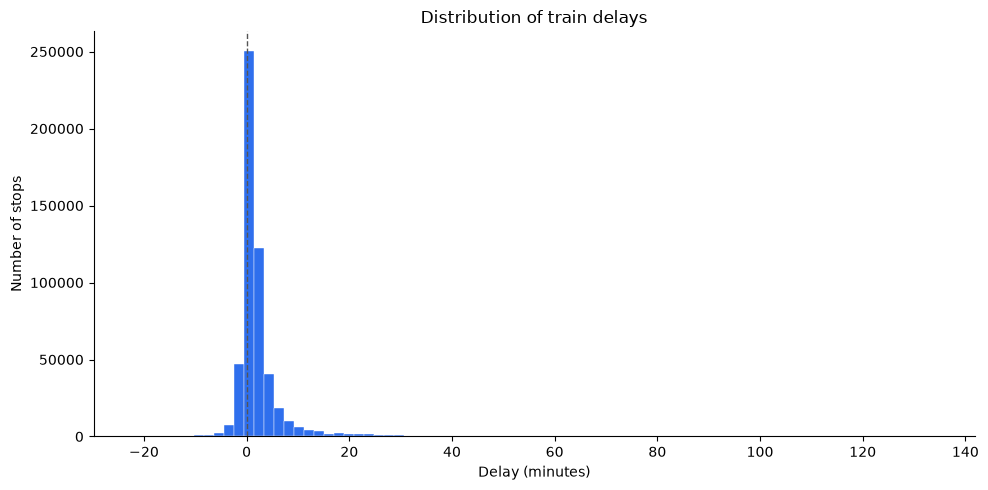

In [4]:
import matplotlib.pyplot as plt

#plot the distribution of train delays, clipped to the 0.1-99.9th percentile to avoid extreme outliers squashing the view
delay = df['differenceInMinutes'].dropna()
lower, upper = delay.quantile([0.001, 0.999])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(delay.clip(lower, upper), bins=80, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='#555555', linewidth=1, linestyle='--')
ax.set_title('Distribution of train delays')
ax.set_xlabel('Delay (minutes)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

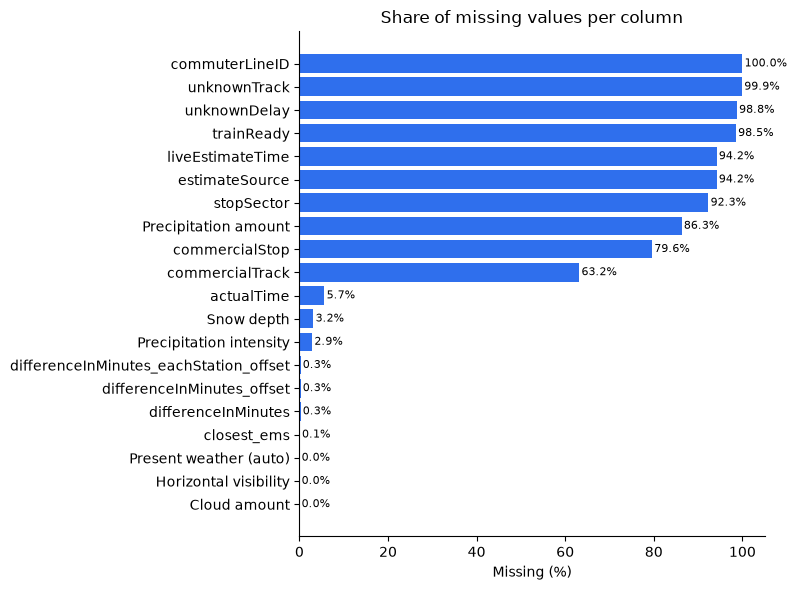

In [5]:
#data quality: share of missing values per column, only columns with at least one missing value
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_pct))))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color='#2F6FED')
for y, v in enumerate(missing_pct.values[::-1]):
    ax.text(v + 0.5, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, 105)
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per column')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

We see the share of missing values per column is unusually high for Precipitation Amount, which is a feature we need for training. We need to make sure that a NaN value means that no precipitation was recorded at the time of the stop. Also features we need such as snow depth and precipitation intensity both have over 4% of missing data.

Next we will plot and analyze the high missing precipitation values.

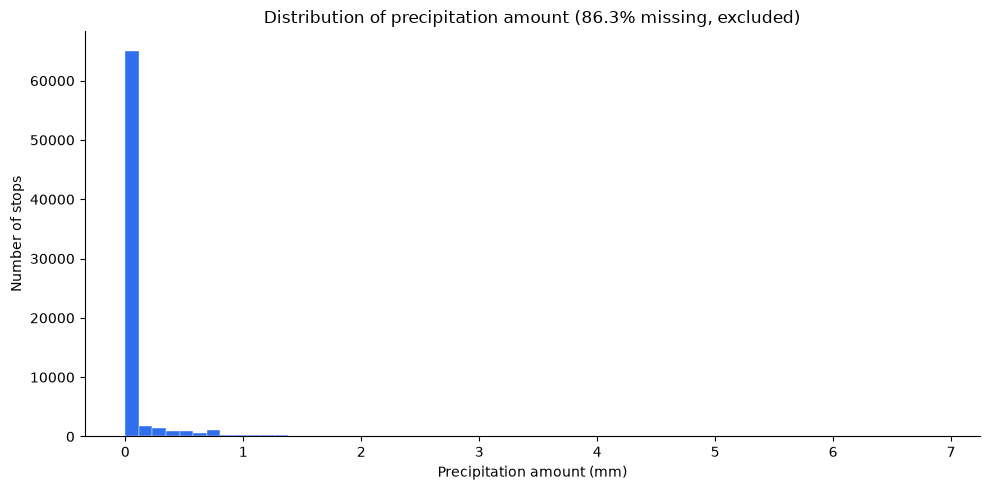

In [6]:
#plot the distribution of precipitation amount 
precip = df['Precipitation amount']
missing_share = precip.isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(precip.dropna(), bins=60, color='#2F6FED', edgecolor='white', linewidth=0.3)
ax.set_title(f'Distribution of precipitation amount ({missing_share:.1f}% missing, excluded)')
ax.set_xlabel('Precipitation amount (mm)')
ax.set_ylabel('Number of stops')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
precip = df['Precipitation amount']

print(f"Exactly 0.0: {(precip == 0).sum():,} ({(precip == 0).mean()*100:.1f}%)")
print(f"Non-null and non-zero: {((precip.notna()) & (precip != 0)).sum():,}")
print()
print("Null values:")
print(f"Total null values: {precip.isna().sum():,} ({precip.isna().mean()*100:.1f}%)")
print()
print("Top 10 most common non-null values:")
print(precip.value_counts(dropna=True).head(10))

Exactly 0.0: 61,291 (11.4%)
Non-null and non-zero: 12,451

Null values:
Total null values: 463,982 (86.3%)

Top 10 most common non-null values:
Precipitation amount
0.0    61291
0.1     3775
0.2     1840
0.3     1374
0.4      954
0.5      905
0.7      592
0.6      566
0.8      429
1.0      315
Name: count, dtype: int64


As we can see the missing values do not mean that there was 0 mm of precipitation. They are missing values and the whole column should be deleted because most of the data is missing (86%).

---

## Data Preparation

We will now proceed to select only the necessary columns needed for training and cleaning the data from selected features. 

We decided to use the following features for training:

- `stationShortCode` - the station, used for grouping/clustering
- `trainNumber`, `departureDate` - together identify one train run, needed to follow a train from stop to stop (see *Measuring the delay a station adds* below)
- `scheduledTime` - used to put the stops of a train run in the right order
- `type` - whether the row is the train's `ARRIVAL` or `DEPARTURE` at the station
- `trainStopping` - whether the train actually stopped at the station
- `differenceInMinutes` - how late the train was at this timetable event (used to derive the target variable)
- `causes` - official delay cause codes, used to check whether weather is ever recorded as a cause
- `Air temperature`
- `Wind speed`
- `Relative humidity`
- `Precipitation intensity`
- `Snow depth`
- `Pressure (msl)`
- `Horizontal visibility`
- `Cloud amount`
- `Present weather (auto)` - coded weather phenomenon observed at the time of the stop

We dropped the 12h/24h/72h rolling-window aggregates since we only need the instantaneous observations, `Precipitation amount` (86% missing), `Dew-point temperature`, `Wind direction` and `Gust speed`, and all operational/administrative columns not related to weather or delay such as operator codes, timetable metadata, etc.

These features will provide enough metrics for finding the most weather-prone train stations.

In [8]:
selected_cols = [
    'trainNumber',
    'departureDate',
    'stationShortCode',
    'scheduledTime',
    'type',
    'differenceInMinutes',
    'causes',
    'trainStopping',
    'Air temperature',
    'Wind speed',
    'Relative humidity',
    'Precipitation intensity',
    'Snow depth',
    'Pressure (msl)',
    'Horizontal visibility',
    'Cloud amount',
    'Present weather (auto)',
]

#read only the selected columns directly from the parquet file (columnar format, so this skips loading the rest)
df_selected = pd.read_parquet(file, columns=selected_cols)

#downcast floats to save memory, and turn the repeat-heavy station code into a category
float_cols = df_selected.select_dtypes(include='float64').columns
df_selected[float_cols] = df_selected[float_cols].astype('float32')
df_selected['stationShortCode'] = df_selected['stationShortCode'].astype('category')

After extracting only the columns we need and downcasting, we are able to import the whole 96 months of data to a singular dataframe.

In [9]:
import time

#load every monthly parquet file from 2018-01 to 2025-12, keeping only the selected columns
months = pd.period_range('2018-01', '2025-12', freq='M')
frames = []
failed = []

start = time.time()
for period in months:
    month_file = Path(path) / f"matched_data_flat_{period.strftime('%Y_%m')}.parquet"
    try:
        month_df = pd.read_parquet(month_file, columns=selected_cols)
    except Exception as e:
        failed.append((month_file.name, str(e)))
        continue

    float_cols = month_df.select_dtypes(include='float64').columns
    month_df[float_cols] = month_df[float_cols].astype('float32')
    month_df['stationShortCode'] = month_df['stationShortCode'].astype('category')
    month_df['causes'] = month_df['causes'].astype('category')
    month_df['type'] = month_df['type'].astype('category')
    month_df['departureDate'] = month_df['departureDate'].astype('category')
    frames.append(month_df)

df_all = pd.concat(frames, ignore_index=True)
df_all['stationShortCode'] = df_all['stationShortCode'].astype('category')
df_all['causes'] = df_all['causes'].astype('category')
df_all['type'] = df_all['type'].astype('category')
df_all['departureDate'] = df_all['departureDate'].astype('category')

elapsed = time.time() - start
print(f"Loaded {len(frames)}/{len(months)} months in {elapsed:.1f}s")
if failed:
    print("Failed months:")
    for name, err in failed:
        print(f"  {name}: {err}")

print(f"Rows: {len(df_all):,}")
print(f"Columns: {len(df_all.columns)}")
print(f"Memory: {df_all.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

df_all.describe(include='all')

Loaded 96/96 months in 9.5s
Rows: 47,956,194
Columns: 17
Memory: 3.93 GB


,trainNumber,departureDate,stationShortCode,scheduledTime,type,differenceInMinutes,causes,trainStopping,Air temperature,Wind speed,Relative humidity,Precipitation intensity,Snow depth,Pressure (msl),Horizontal visibility,Cloud amount,Present weather (auto)
count,4.795619e+07,47956194,47956194,47956194,47956194,4.743210e+07,47956194,47956194,4.794273e+07,4.793354e+07,4.794273e+07,4.671124e+07,4.656335e+07,4.794189e+07,4.793717e+07,4.776361e+07,4.793414e+07
unique,NaN,2922,553,8947002,2,NaN,255,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2020-02-07,PSL,2019-02-24T17:38:00.000Z,ARRIVAL,NaN,[],False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,20940,646075,36,23978097,NaN,47409857,37579076,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,3.582276e+02,NaN,NaN,NaN,NaN,3.736408e+00,NaN,NaN,6.484986e+00,3.802288e+00,7.766042e+01,7.718372e-02,7.682606e+00,1.011625e+03,3.610370e+04,4.898395e+00,1.613681e+01
std,1.151368e+03,NaN,NaN,NaN,NaN,1.350311e+01,NaN,NaN,9.989645e+00,2.140898e+00,1.934145e+01,6.088824e-01,1.542015e+01,1.169856e+01,1.984193e+04,3.422856e+00,2.849657e+01
min,1.000000e+00,NaN,NaN,NaN,NaN,-6.950000e+02,NaN,NaN,-3.920000e+01,0.000000e+00,4.000000e+00,0.000000e+00,-1.000000e+00,9.467000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.800000e+01,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,-3.000000e-01,2.300000e+00,6.500000e+01,0.000000e+00,-1.000000e+00,1.004600e+03,2.000000e+04,0.000000e+00,0.000000e+00
50%,9.400000e+01,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,5.700000e+00,3.500000e+00,8.400000e+01,0.000000e+00,0.000000e+00,1.012300e+03,4.017000e+04,7.000000e+00,0.000000e+00
75%,3.220000e+02,NaN,NaN,NaN,NaN,3.000000e+00,NaN,NaN,1.450000e+01,5.000000e+00,9.300000e+01,0.000000e+00,1.000000e+01,1.019400e+03,5.000000e+04,8.000000e+00,2.200000e+01


The features look mostly natural, but we do notice that the minimum value for `differenceInMinutes` is -695 minutes which is a clear outlier that should be assessed.

In [10]:
delay = (
    df_all["differenceInMinutes"]
    .dropna()
    .sort_values(ascending=True)
    .head(1000)
)

print("First 10 of the first 1000:")
print(delay.head(10))
print()
print("Last 10 of the first 1000:")
print(delay.tail(10))

First 10 of the first 1000:
21725226   -695.0
21725231   -674.0
21725233   -674.0
44761100   -673.0
44761101   -673.0
21725225   -654.0
29112954   -569.0
15977531   -233.0
25168711   -232.0
16025339   -223.0
Name: differenceInMinutes, dtype: float32

Last 10 of the first 1000:
29130151   -96.0
3666275    -95.0
46076269   -95.0
17569491   -95.0
17569492   -95.0
42550748   -95.0
3666276    -95.0
17936797   -95.0
1622375    -95.0
13584843   -95.0
Name: differenceInMinutes, dtype: float32


When ordered by `differenceInMinutes` (ascending) we see a large variation in just the first 1000 rows alone. The first ones are around -600 minutes and the last ones around -95 minutes, meaning that these outliers should not make a big difference as the data is very large (48 million rows).

### Keeping only real stops, and only one row per stop

Before handling missing values we have to fix two things. We only count stops where the train actually stopped (`trainStopping == True`). Non-stopping records make up a large share of rows at stations with low traffic. We want to keep only the rows where a train actually stopped because that is the delay experienced by passengers and is more meaningful for evaluation.

Every stop is stored twice in the dataset, once for an `ARRIVAL` event and once for a `DEPARTURE` event which means that we count every stop twice. We keep the `DEPARTURE` row because it includes everything everything that happened to the train until leaving the station, both the track leading to the station and the time spent on platform. This is also what the daly metric in the next step needs.

In [11]:
#how many stopping rows are arrivals vs. departures - if the two are ~equal, every stop is in the data twice
stopping = df_all[df_all['trainStopping']]
print("Rows per event type at real stops:")
print(stopping['type'].value_counts())
print()

#keep only stopping DEPARTURE rows -> exactly one row per (train run, station)
rows_before = len(df_all)
df_all = df_all[df_all['trainStopping'] & (df_all['type'] == 'DEPARTURE')].drop(columns=['trainStopping', 'type']).reset_index(drop=True)
df_all['stationShortCode'] = df_all['stationShortCode'].cat.remove_unused_categories()
del stopping
rows_after = len(df_all)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.1f}%)")
print(f"Stations remaining: {df_all['stationShortCode'].nunique()}")

Rows per event type at real stops:
type
ARRIVAL      5188559
DEPARTURE    5188559
Name: count, dtype: int64



Rows before: 47,956,194
Rows after:  5,188,559
Dropped:     42,767,635 (89.2%)
Stations remaining: 500


### Measuring the delay added between stops

The `differenceInMinutes` column shows how late a train is at a certain point in its journey. The problem is that the delay might have started much earlier. For example, if a train becomes 10 minutes late near Riihimäki, it can still be 10 minutes late at the next stations, even if nothing happens there.

If we only use the total delay, some stations might look more affected by bad weather than they actually are. That's why we decided to look at how much the delay changes between stops.

**Calculating the added delay**

We created a new variable called `delay_added`. First, we arrange the data by departure date, train number and scheduled time. Then we compare the delay at each stop with the delay at the previous stop.

`delay_added = current delay - previous delay`

For the first stop, we use the recorded delay because there is no previous stop to compare it with.

This gives us a better understanding of where the delay increased during the journey. However, we cannot say for sure that the delay was caused by that specefic station or by the weather.

**Handling negative and extreme values**

We also made two adjustments:

- **Negative values are set to 0.** These mean that the train has caught up some time. Since we want to study increases in delay, we don't include these negative changes.
- **Very large values are limited to the 99.9th percentile.** A few unusually large delays could affect the averages too much, especially at stations with fewer observations.

Because of these adjustments, the added delays do not always add up to the train's final delay.

We calculate `delay_added` before removing rows with missing weather data. Otherwise, removing a stop could make the next stop include delay changes from more than one part of the journey.

In [12]:
import numpy as np

#put the stops of every train run in timetable order
df_all = df_all.sort_values(['departureDate', 'trainNumber', 'scheduledTime']).reset_index(drop=True)
run = df_all.groupby(['departureDate', 'trainNumber'], observed=True)['differenceInMinutes']

#departure delay at the previous stop of the same run (NaN for the first stop of a run)
previous_delay = run.shift()
is_first_stop = df_all.groupby(['departureDate', 'trainNumber'], observed=True).cumcount() == 0

#delay picked up since the previous stop. At the starting station the whole departure delay was created there
df_all['delay_added'] = np.where(is_first_stop, df_all['differenceInMinutes'], df_all['differenceInMinutes'] - previous_delay).astype('float32')

#example: one train run, to show the difference between total delay and delay added
example_run = df_all.loc[df_all['trainNumber'] == 1, 'departureDate'].iloc[100]
print(f"Example: train 1 on {example_run}")
print(df_all[(df_all['trainNumber'] == 1) & (df_all['departureDate'] == example_run)][['stationShortCode', 'scheduledTime', 'differenceInMinutes', 'delay_added']].to_string(index=False))
print()

#only count delay gained (catching up is not the station's merit in bad weather), and cap broken extreme values
upper_cap = df_all['delay_added'].quantile(0.999)
df_all['delay_added'] = df_all['delay_added'].clip(lower=0, upper=upper_cap)
print(f"delay_added capped to [0, {upper_cap:.0f}] minutes")
print(f"Share of first stops of a run: {is_first_stop.mean() * 100:.1f}%")

#the total delay is not needed any more - from here on delay_added is the target
df_all = df_all.drop(columns=['differenceInMinutes', 'trainNumber', 'departureDate'])
del run, previous_delay, is_first_stop
df_all['delay_added'].describe()

`delay_added` is `NaN` when the train's own delay was not recorded at this stop or the previous one (about 1.5% of the rows). These rows are removed together with the missing weather values below.

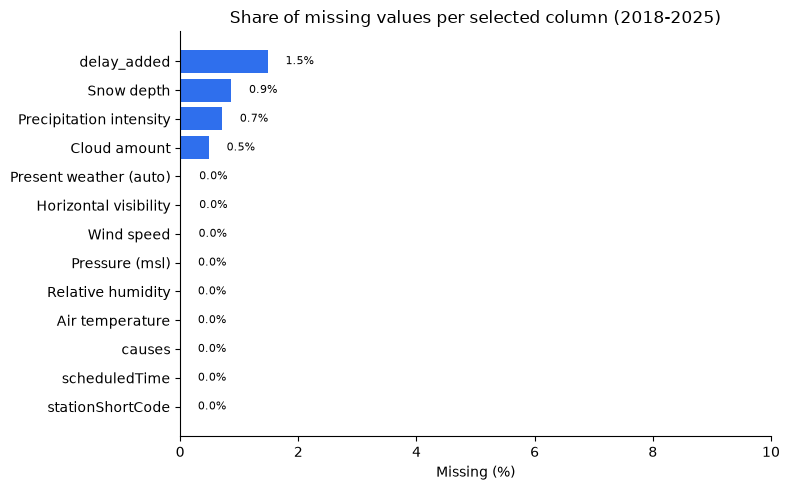

In [13]:
#share of missing values per selected column, across the full 2018-2025 dataset
missing_pct = (df_all.isna().mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(missing_pct.index, missing_pct.values, color='#2F6FED')
for y, v in enumerate(missing_pct.values):
    ax.text(v + 0.3, y, f'{v:.1f}%', va='center', fontsize=8)
ax.set_xlim(0, max(10, missing_pct.max() * 1.15))
ax.set_xlabel('Missing (%)')
ax.set_title('Share of missing values per selected column (2018-2025)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [14]:
#share of rows that have at least one missing value across the selected columns
rows_with_missing = df_all.isna().any(axis=1).mean() * 100
print(f"Rows with at least one missing value: {rows_with_missing:.1f}%")

Rows with at least one missing value: 2.9%


We decided to delete rows with missing data because predicting or replacing the missing values with the mean for weather features can skew the data. For example, calculating mean for missing snow-depth values could lead to warm months like July having a filled mean value, which does not make sense.


In [15]:
#drop rows with any missing values across the selected columns
rows_before = len(df_all)
df_all = df_all.dropna().reset_index(drop=True)
rows_after = len(df_all)

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {rows_after:,}")
print(f"Dropped:     {rows_before - rows_after:,} ({(rows_before - rows_after) / rows_before * 100:.1f}%)")

Rows before: 5,188,559
Rows after:  5,039,903
Dropped:     148,656 (2.9%)


### Station-level aggregation

Next we will group the data by a station's `stationShortCode`. For every station, we calculate the means of: every weather feature (only for describing the clusters later), the `delay_added` in good weather cases, as well as the `delay_added` separately in rainy, freezing temperature and snowy cases.

The mean of `delay_added` in good weather conditions acts as a station's baseline. This is because we are measuring how much worse the delays can grow when facing poor weather conditions.

We define "good weather" as the opposite of these conditions together:
1. No precipitation (precipitation intensity = 0)
2. Temperature is above freezing (air temperature > 0)
3. No snow on the ground (snow depth <= 0) (the weather data states no snow as -1)

Below we find out that around 58% of all stops happen under good weather conditions so the baseline is therefore feasible as it's based on lots of data.

In [16]:
#overall per-station stop count and weather averages (climate columns are used only to describe clusters)
station_features = (
    df_all
    .groupby('stationShortCode', observed=True)
    .agg(
        stop_count=('delay_added', 'size'),
        mean_air_temperature=('Air temperature', 'mean'),
        mean_wind_speed=('Wind speed', 'mean'),
        mean_relative_humidity=('Relative humidity', 'mean'),
        mean_precipitation_intensity=('Precipitation intensity', 'mean'),
        mean_snow_depth=('Snow depth', 'mean'),
        mean_pressure=('Pressure (msl)', 'mean'),
        mean_horizontal_visibility=('Horizontal visibility', 'mean'),
        mean_cloud_amount=('Cloud amount', 'mean'),
    )
    .reset_index()
)

#mean delay added per station, split by weather condition, to capture weather-specific vulnerability.
#a condition built from fewer than MIN_CONDITION_STOPS stops is blanked out -> too small a sample to
#trust, and prone to being skewed by a single extreme delay event
MIN_CONDITION_STOPS = 30

rain_mask = df_all['Precipitation intensity'] > 0
freezing_mask = df_all['Air temperature'] < 0
snow_mask = df_all['Snow depth'] > 0
#good weather = none of the bad-weather conditions -> the baseline the conditions are compared against
good_mask = ~(rain_mask | freezing_mask | snow_mask)

print("Share of stops per condition (rain/freezing/snow can overlap):")
for mask, label in [(good_mask, 'good weather'), (rain_mask, 'rain'), (freezing_mask, 'freezing'), (snow_mask, 'snow')]:
    print(f"  {label:<13} {mask.mean() * 100:5.1f}%   mean delay added {df_all.loc[mask, 'delay_added'].mean():.2f} min")
print()

def delay_by_station(mask, name):
    grouped = df_all[mask].groupby('stationShortCode', observed=True)['delay_added']
    result = grouped.agg(**{name: 'mean', f'{name}_n': 'size'}).reset_index()
    result.loc[result[f'{name}_n'] < MIN_CONDITION_STOPS, name] = np.nan
    return result.drop(columns=f'{name}_n')

condition_masks = [
    (good_mask, 'mean_delay_added_good'),
    (rain_mask, 'mean_delay_added_rain'),
    (freezing_mask, 'mean_delay_added_freezing'),
    (snow_mask, 'mean_delay_added_snow'),
]

for mask, name in condition_masks:
    station_features = station_features.merge(delay_by_station(mask, name), on='stationShortCode', how='left')

print(f"Stations: {len(station_features)}")
station_features.sort_values('stop_count', ascending=False).head(10)

Share of stops per condition (rain/freezing/snow can overlap):
  good weather   58.3%   mean delay added 0.99 min
  rain            7.0%   mean delay added 1.24 min
  freezing       26.6%   mean delay added 1.30 min
  snow           33.4%   mean delay added 1.25 min



Stations: 493


,stationShortCode,stop_count,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,mean_delay_added_good,mean_delay_added_rain,mean_delay_added_freezing,mean_delay_added_snow
316,PSL,312993,8.024956,4.517106,75.809158,0.085087,5.128572,1012.234985,33628.292969,4.397725,0.856978,0.984968,0.982778,0.956551
406,TKL,246739,7.761536,3.651274,76.035652,0.088776,5.444863,1012.228638,32361.988281,4.884712,1.164981,1.490565,1.668695,1.581994
420,TPE,208051,6.583096,4.997983,77.994431,0.074502,6.733916,1011.429749,37756.800781,5.091016,1.973742,2.615943,3.012457,2.847690
31,HKI,158483,8.089185,4.137436,75.450218,0.077425,2.868112,1012.292786,34005.492188,4.439763,1.282097,1.786603,2.356524,2.278396
411,TL,123038,6.700623,3.391115,79.570473,0.068957,5.529308,1011.674927,43338.917969,5.057803,0.576854,0.766723,0.865924,0.848077
373,SK,110724,5.644366,3.132513,79.163933,0.073863,5.936599,1010.922607,42454.253906,4.933854,2.643769,3.250545,3.753556,3.544500
169,KV,101368,6.727693,3.905444,75.308319,0.080942,6.359778,1011.908936,45574.726562,5.116565,1.247905,1.545046,1.666948,1.736990
342,RI,90877,6.663095,2.738422,80.377510,0.084665,7.341671,1012.164124,30938.957031,5.003973,0.600956,0.843702,0.951515,0.882072
35,HL,90123,6.758854,3.510869,77.207275,0.066673,5.860380,1011.552734,33532.687500,4.841084,0.508792,0.602545,0.692065,0.645209
185,LH,88991,7.043692,3.639432,74.980301,0.076189,7.594858,1011.980957,30015.500000,5.101257,0.917405,1.360585,1.543380,1.592850


In [17]:
#check whether the dropped NaN stations are just low-traffic ones or something worth worrying about
condition_cols = ['mean_delay_added_good', 'mean_delay_added_rain', 'mean_delay_added_freezing', 'mean_delay_added_snow']
has_nan = station_features[condition_cols].isna().any(axis=1)

print(f"Stations with at least one NaN condition-delay: {has_nan.sum()} / {len(station_features)}")
print()
print("stop_count for stations WITH NaNs:")
print(station_features.loc[has_nan, 'stop_count'].describe())
print()
print("stop_count for stations WITHOUT NaNs:")
print(station_features.loc[~has_nan, 'stop_count'].describe())
print()
print("Highest-traffic stations that still have a NaN :")
station_features.loc[has_nan].sort_values('stop_count', ascending=False).head(10)

Stations with at least one NaN condition-delay: 274 / 493

stop_count for stations WITH NaNs:
count     274.000000
mean       45.941606
std       106.761915
min         1.000000
25%         2.000000
50%         7.000000
75%        41.500000
max      1183.000000
Name: stop_count, dtype: float64

stop_count for stations WITHOUT NaNs:
count       219.000000
mean      22955.776256
std       36597.982531
min         376.000000
25%        3240.500000
50%       11628.000000
75%       28916.500000
max      312993.000000
Name: stop_count, dtype: float64

Highest-traffic stations that still have a NaN :


,stationShortCode,stop_count,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount,mean_delay_added_good,mean_delay_added_rain,mean_delay_added_freezing,mean_delay_added_snow
36,HLS,1183,16.371174,4.055368,63.810650,0.079290,-0.639053,1013.127014,58881.359375,4.124260,1.748644,2.145455,NaN,NaN
66,IKO,698,18.999857,5.718051,74.829514,0.122350,-0.316619,1013.486572,38640.468750,3.071633,2.617785,3.195122,NaN,NaN
421,TPET,385,6.662078,4.835325,77.361038,0.049351,7.311688,1012.175110,38512.230469,4.794805,6.720524,NaN,7.096774,8.416667
225,MJJ,384,0.676563,5.070312,84.406250,0.035677,10.273438,1009.190918,36186.570312,5.190104,2.083333,NaN,2.000000,2.217822
456,VKO,371,7.668464,3.238814,76.126686,0.142049,7.671159,1010.582703,47711.613281,4.978436,6.351695,NaN,2.916667,2.761468
0,AHO,311,-1.709646,3.855305,85.536980,0.063987,6.929260,1001.395203,39029.414062,5.096463,0.763889,NaN,1.127273,1.367647
65,II,304,1.775329,5.616776,80.953949,0.060197,17.460526,1007.315796,33552.386719,4.753290,2.419048,NaN,2.638462,2.584270
296,PKU,301,10.596013,5.548505,84.126244,0.047841,4.156146,1013.712952,33717.011719,3.079734,1.651376,NaN,1.218750,1.328767
380,SLN,292,7.498631,2.406507,74.243149,0.073288,10.743151,1010.111328,39464.726562,4.424657,1.793103,NaN,3.698795,3.235294
104,KE,274,8.228468,4.528467,75.018250,0.092701,5.726277,1014.404419,40413.285156,4.321168,10.137143,NaN,14.333333,17.314285


This justifies our reason to drop all stations with NaN values, as they have too few stops to have any real value on our model.

#### Scaling and dropping small stations with NaN's

After verifying that most of the stations with NaN values are with little traffic. We decided to drop all of them and after that standardize the data and prepare it for K-means.



In [18]:
from sklearn.preprocessing import StandardScaler

#drop any station still carrying a NaN (StandardScaler can't handle them) before scaling
station_features_clean = station_features.dropna().reset_index(drop=True)
print(f"Stations: {len(station_features)} -> {len(station_features_clean)} after dropping remaining NaNs")

#use delay EXCESS relative to each station's own GOOD-WEATHER baseline, instead of the raw condition delays -
#the raw ones are strongly correlated with the baseline (and with each other), so clustering would mostly
#pick up "how delay-prone is this station overall" rather than weather-specific sensitivity
for condition in ['rain', 'freezing', 'snow']:
    station_features_clean[f'excess_delay_{condition}'] = station_features_clean[f'mean_delay_added_{condition}'] - station_features_clean['mean_delay_added_good']

#we cluster ONLY on delay and its weather-specific excess - clustering on the climate averages too would
#group stations by climate zone (cold/snowy north vs mild south) rather than by actual weather sensitivity.
#the climate columns are kept, scaled the same way, and used afterwards only to describe each cluster
cluster_cols = ['mean_delay_added_good', 'excess_delay_rain', 'excess_delay_freezing', 'excess_delay_snow']
climate_cols = [
    'mean_air_temperature',
    'mean_wind_speed',
    'mean_relative_humidity',
    'mean_precipitation_intensity',
    'mean_snow_depth',
    'mean_pressure',
    'mean_horizontal_visibility',
    'mean_cloud_amount',
]
profile_cols = cluster_cols + climate_cols

scaler = StandardScaler()
scaled_features = scaler.fit_transform(station_features_clean[profile_cols])

scaled_df = pd.DataFrame(scaled_features, columns=profile_cols, index=station_features_clean['stationShortCode'])
scaled_df.head(30)

Stations: 493 -> 219 after dropping remaining NaNs


,mean_delay_added_good,excess_delay_rain,excess_delay_freezing,excess_delay_snow,mean_air_temperature,mean_wind_speed,mean_relative_humidity,mean_precipitation_intensity,mean_snow_depth,mean_pressure,mean_horizontal_visibility,mean_cloud_amount
stationShortCode,,,,,,,,,,,,
AHV,-0.030515,1.395461,0.500003,0.399976,1.268859,0.180493,-2.102219,-2.575990,-1.283474,0.340760,-0.335614,-0.484048
ALV,-0.353489,-0.723445,-0.881857,-0.955513,-0.226859,-0.752659,0.857626,-0.067643,0.005154,-0.027391,-2.027696,0.615250
APT,1.373818,0.692249,-0.865681,-0.590502,-0.381323,-0.406373,0.251268,0.607935,0.631104,-0.317046,1.315557,1.184725
DRA,-0.444851,-0.164478,-0.327639,-0.152192,0.920158,3.159113,1.093635,-0.724266,-1.432536,1.153106,-0.231448,-3.016128
ENO,-0.450513,-0.060311,-0.351385,-0.306030,0.211366,-0.046346,-1.142304,0.610260,0.509883,0.481574,0.949985,1.040519
EPZ,-0.925853,-0.537526,-0.475179,-0.430630,0.182342,-0.829228,-0.117053,-0.342690,0.114776,0.089954,-1.910536,0.498633
ERV,0.766164,-0.612869,-0.271453,-0.014743,3.191680,-0.014784,-1.939463,-0.666956,-1.339375,1.139932,-0.400026,-1.092569
HD,-0.080844,-0.008491,-1.313886,-1.247226,-1.327954,1.124822,1.157954,-0.225097,0.298055,-1.268368,-1.495332,-0.219472
HKI,0.352497,0.966473,2.320048,2.340138,1.293409,0.369669,-0.872147,0.572444,-1.233870,1.030492,-0.134032,-1.544666


# Modeling

After succesfully preparing the data we proceed to create the model. We start by finding the optimal amount of clusters (`k`). For this, we start with the elbow-method to try and point out the optimal K-Value.

#### Finding the right K-value

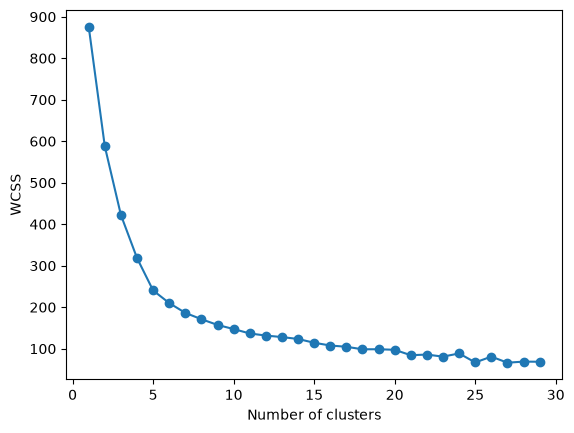

In [19]:
from sklearn.cluster import KMeans

#determine the optimal number of clusters using the elbow method - fit only on cluster_cols,
#the climate columns in scaled_df are for description, not for driving the clustering
wcss = []
for i in range(1,30):
    model = KMeans(init="random", n_clusters=i, random_state=42).fit(scaled_df[cluster_cols])
    wcss.append(model.inertia_)
    
plt.plot(range(1,30), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

We notice that the "elbow" is at 4, which we will take into consideration for the K-value. To double-check and verify we also calculate the silhouette scores as the elbow-method is not enough by its own.

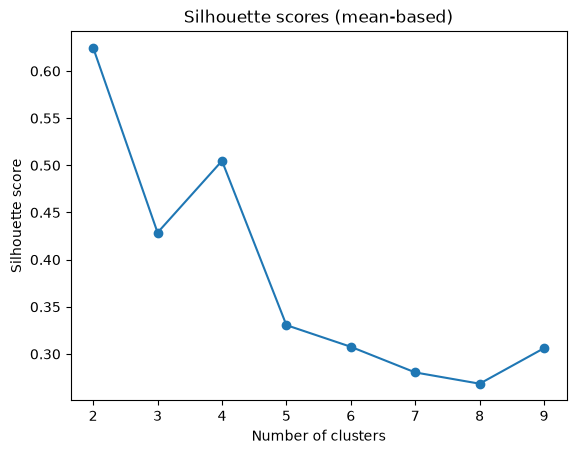

Silhouette scores:
[0.6247332692146301, 0.4286574125289917, 0.5047529935836792, 0.3305666148662567, 0.30760401487350464, 0.28041115403175354, 0.26848167181015015, 0.30616411566734314]


In [20]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for i in range(2, 10):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(scaled_df[cluster_cols])
    silhouette_scores.append(silhouette_score(scaled_df[cluster_cols], model.labels_))

def plot_silhouette_scores(scores, range_min = 2, range_max = 10, title = None):
    plt.plot(range(range_min, range_max), scores, 'o-')
    if title: plt.title(title)
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette score')
    plt.show()

plot_silhouette_scores(silhouette_scores, 2, 10, 'Silhouette scores (mean-based)')

print(f'Silhouette scores:\n{silhouette_scores}')

As we can read from the graph k-value 2 has the best silhoutte scores of over 0.60. K-value 4 looks also promising. We now test both k-values.

In [21]:
#fit both candidate k-values side by side, so they can be compared before choosing one
CANDIDATE_KS = [2, 4]
excess_cols = ['excess_delay_rain', 'excess_delay_freezing', 'excess_delay_snow']
station_excess = station_features_clean[excess_cols].mean(axis=1).to_numpy()

#K-means numbers clusters arbitrarily, so relabel them by mean weather excess: cluster 0 = highest excess
#(most weather-vulnerable). This makes the labels comparable between the two k-values
def relabel_by_excess(labels):
    excess_per_label = pd.Series(station_excess).groupby(labels).mean()
    relabel = {old: new for new, old in enumerate(excess_per_label.sort_values(ascending=False).index)}
    return np.array([relabel[label] for label in labels])

candidate_labels = {}
for k in CANDIDATE_KS:
    model = KMeans(n_clusters=k, init='random', random_state=42).fit(scaled_df[cluster_cols])
    candidate_labels[k] = relabel_by_excess(model.labels_)
    sizes = pd.Series(candidate_labels[k]).value_counts().sort_index()
    score = silhouette_score(scaled_df[cluster_cols], candidate_labels[k])
    print(f"k={k}: silhouette {score:.3f}, cluster sizes {sizes.tolist()}")

k=2: silhouette 0.625, cluster sizes [18, 201]
k=4: silhouette 0.505, cluster sizes [1, 33, 174, 11]


In [22]:
#mean profile of each cluster for both k-values (cluster 0 = highest weather excess in both)
profiles = []
for k in CANDIDATE_KS:
    profile = (
        station_features_clean[['stop_count'] + cluster_cols]
        .groupby(candidate_labels[k])
        .agg(['mean'])
        .droplevel(1, axis=1)
    )
    profile.insert(0, 'stations', pd.Series(candidate_labels[k]).value_counts().sort_index())
    profile.index = pd.MultiIndex.from_product([[f'k={k}'], profile.index], names=['k', 'cluster'])
    profiles.append(profile)

pd.concat(profiles).round(2)

stations  stop_count  mean_delay_added_good  excess_delay_rain  \
k   cluster                                                                   
k=2 0              18    47056.67                   2.47               0.83   
    1             201    20797.49                   0.80               0.11   
k=4 0               1     1642.00                  10.25               1.59   
    1              33    41164.85                   1.56               0.64   
    2             174    20805.49                   0.69               0.12   
    3              11     4279.82                   2.07              -0.55   

             excess_delay_freezing  excess_delay_snow  
k   cluster                                            
k=2 0                         0.99               0.89  
    1                         0.09               0.07  
k=4 0                         3.41               3.18  
    1                         0.63               0.58  
    2                         0.09               0.07  
    3                        -0.45              -0.48

In [23]:
#which k=2 cluster do the k=4 clusters come from? (rows: k=4, columns: k=2, 0 = most weather-vulnerable)
print(pd.crosstab(candidate_labels[4], candidate_labels[2], rownames=['k=4'], colnames=['k=2']))
print()

#list the stations of the smaller k=4 clusters
labels_k4 = pd.Series(candidate_labels[4], index=station_features_clean['stationShortCode'])
for label, stations in labels_k4.groupby(labels_k4):
    if len(stations) <= 40:
        print(f"k=4 cluster {label} ({len(stations)} stations): {', '.join(stations.index)}")

k=2   0    1
k=4         
0     1    0
1    17   16
2     0  174
3     0   11

k=4 cluster 0 (1 stations): ILR
k=4 cluster 1 (33 stations): AHV, HKI, JNS, KEM, KJÄ, KLI, KOK, KRR, KV, KÄP, LH, MD, NMÄ, NRI, OL, PAR, PKK, PKO, PM, PSLT, PTR, RJP, ROI, SK, SPÄ, TKK, TKL, TPE, TUA, VNA, YLV, YLÖ, YV
k=4 cluster 3 (11 stations): JK, KUA, LHS, LMK, LÄ, PIK, PTO, PVI, SIM, TRI, VKI


K=4 splits the "vulnerable" group into 2 extra sections. The "non-vulnerable" group is also split to two. So we chose to use k=2 as the final cluster amount as it splits the stations to "non-vulnerable" to "vulnerable". 

In [24]:
#final choice of k - every cell below uses these labels
K = 2
final_labels = candidate_labels[K]
station_features_clean['cluster'] = final_labels

print(station_features_clean['cluster'].value_counts().sort_index())

cluster
0     18
1    201
Name: count, dtype: int64


### Cluster vulnerability heatmap

The clustering comes only from the median-delay and the excess-delay columns. In the heatmap below we can see all the climate columns used to describe each cluster. 

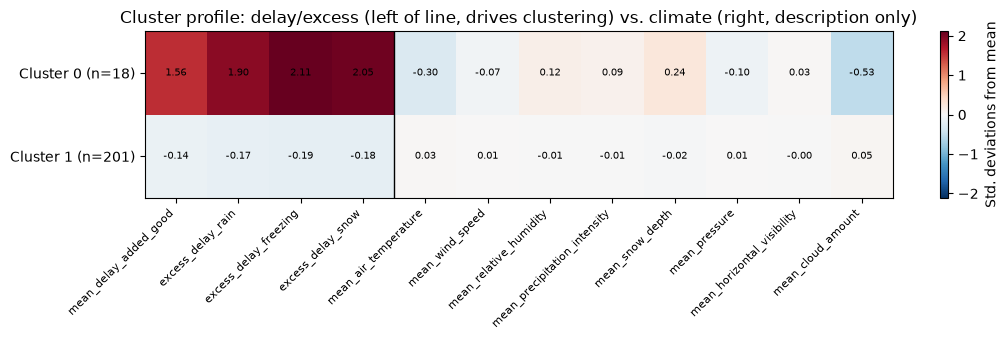

In [25]:
#heatmap of each cluster's mean standardized profile, across both the clustering columns and the
#climate columns (diverging colormap: red = above the overall average, blue = below)
scaled_with_cluster = scaled_df.copy()
scaled_with_cluster['cluster'] = final_labels
cluster_profile = scaled_with_cluster.groupby('cluster')[profile_cols].mean()

fig, ax = plt.subplots(figsize=(11, 3.5))
vmax = cluster_profile.abs().to_numpy().max()
im = ax.imshow(cluster_profile.to_numpy(), aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(profile_cols)))
ax.set_xticklabels(profile_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(cluster_profile)))
ax.set_yticklabels([f'Cluster {i} (n={n})' for i, n in station_features_clean['cluster'].value_counts().sort_index().items()])

#mark the boundary between the clustering columns and the description-only climate columns
ax.axvline(len(cluster_cols) - 0.5, color='black', linewidth=1)

for i in range(cluster_profile.shape[0]):
    for j in range(cluster_profile.shape[1]):
        ax.text(j, i, f'{cluster_profile.to_numpy()[i, j]:.2f}', ha='center', va='center', fontsize=7)

ax.set_title('Cluster profile: delay/excess (left of line, drives clustering) vs. climate (right, description only)')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Std. deviations from mean')
plt.tight_layout()
plt.show()

The heatmap shows the standardized mean profile of each cluster. Cluster 1 (201 stations) is slightly below average on all delay features which indicates less weather-prone stations. Cluster 0 (18 stations) has a higher baseline delay added in good weather (+1.6 std) and an even stronger excess delay during rain (+1.9), freezing temperatures (+2.1) and snow (+2.1). These stations add some delay in normal conditions, and clearly more when the weather is bad.

Values on the right side of the map tell whether the difference is associated with other climate variables, but they are not used as the main clustering features.

### Map of stations by cluster

Plotting every clustered station on a map of Finland using `folium`. Coordinates come from the same source dataset, from a separate `metadata_train_stations.csv` file, joined on `stationShortCode`. 

Cluster 0 (weather-vulnerable): RED 

cluster 1 (near-baseline): BLUE

In [26]:
import folium

#join cluster assignments with station coordinates from the metadata file
metadata = pd.read_csv(metadata_file)
stations_geo = station_features_clean[['stationShortCode', 'cluster']].merge(
    metadata[['stationShortCode', 'stationName', 'latitude', 'longitude']],
    on='stationShortCode',
    how='left',
)

missing_coords = stations_geo['latitude'].isna().sum()
print(f"Stations missing coordinates: {missing_coords} / {len(stations_geo)}")
stations_geo = stations_geo.dropna(subset=['latitude', 'longitude'])

cluster_colors = {0: 'red', 1: 'blue'}

m = folium.Map(location=[64.5, 26.0], zoom_start=5, tiles='OpenStreetMap')

for _, row in stations_geo.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=cluster_colors.get(row['cluster'], 'gray'),
        fill=True,
        fill_color=cluster_colors.get(row['cluster'], 'gray'),
        fill_opacity=0.8,
        popup=f"{row['stationName']} ({row['stationShortCode']}) - cluster {row['cluster']}",
    ).add_to(m)

m

Stations missing coordinates: 0 / 219


### Validation

After clustering the data succesfully the last step is validation and evaluation. Until now all clusters are based on our own intrepetration of weather conditions. We loaded in the beginning a column that includes the official delay causes. We use this data against our own clusters to check our results. The cause codes come from 

The weather conditions and the clusters are based on our intreperations of weather observations. In the beginnig we had a column "causes" and that is the official reason for a train delay. We use this data to validate our KMeans clustering model. The following 2-fields are the only causes related to weather. We will be using these for validation:

`I1` - *Poikkeukselliset sääolosuhteet* (exceptional weather) 

`I2` - *Lehtikeli tai muu liukkaus* (leaves on the track)

The "codes" and their meaning are found from DigiTraffic's railway API.

We mark a stop as having a **weather cause** if either code is recorded on it and after we check if our weather conditions match the official records. Cluster 0 should in theory include every weather-vulnerable station, if its stations have more weather causes recorded.

> **Note:** CAUSE-codes were not used in training.

In [27]:
import ast

#official weather-related delay cause code
WEATHER_CAUSE_CODES = {'I1', 'I2'}

#causes is stored as text like
def has_weather_cause(causes_text):
    try:
        return any(cause.get('detailedCategoryCode') in WEATHER_CAUSE_CODES for cause in ast.literal_eval(causes_text))
    except (ValueError, SyntaxError):
        return False

weather_cause_lookup = {text: has_weather_cause(text) for text in df_all['causes'].cat.categories}
df_all['weather_cause'] = df_all['causes'].map(weather_cause_lookup).astype(bool)
print(f"Stops with an official weather cause: {df_all['weather_cause'].sum():,} of {len(df_all):,}")
print()

#check 1: are weather causes recorded more often in our bad-weather conditions than in good weather?
print("Share of stops with an official weather cause, per condition:")
good_share = df_all.loc[good_mask, 'weather_cause'].mean()
for mask, label in [(good_mask, 'good weather'), (rain_mask, 'rain'), (freezing_mask, 'freezing'), (snow_mask, 'snow')]:
    share = df_all.loc[mask, 'weather_cause'].mean()
    print(f"  {label:<13} {share * 100:.3f}%   ({share / good_share:.1f}x good weather)")
print()

#check 2: do the stations in the vulnerable cluster have weather causes recorded more often?
station_weather_cause = (df_all.groupby('stationShortCode', observed=True)['weather_cause'].mean() * 100).rename('weather_cause_share')
station_features_clean = station_features_clean.drop(columns='weather_cause_share', errors='ignore').merge(
    station_weather_cause, left_on='stationShortCode', right_index=True, how='left')

groups = {c: station_features_clean.loc[station_features_clean['cluster'] == c, 'weather_cause_share'] for c in sorted(station_features_clean['cluster'].unique())}

print("Share of stops (%) with an official weather cause, per cluster:")
print(station_features_clean.groupby('cluster')['weather_cause_share'].agg(['mean', 'median', 'size']))
print()

Stops with an official weather cause: 802 of 5,039,903

Share of stops with an official weather cause, per condition:
  good weather  0.002%   (1.0x good weather)
  rain          0.080%   (39.8x good weather)
  freezing      0.050%   (24.8x good weather)
  snow          0.043%   (21.2x good weather)

Share of stops (%) with an official weather cause, per cluster:
             mean    median  size
cluster                          
0        0.030471  0.019266    18
1        0.004656  0.000000   201



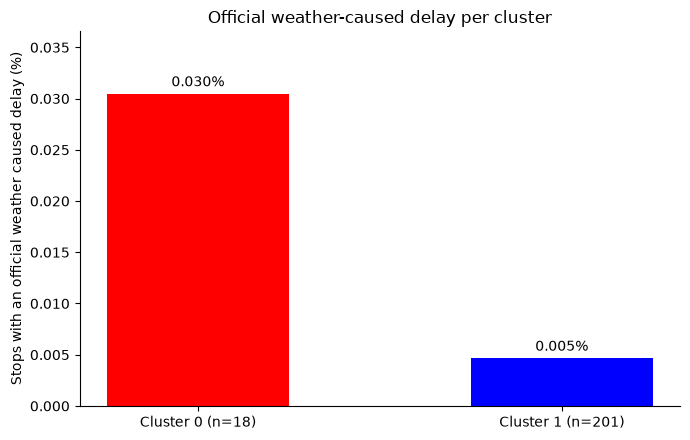

In [28]:
#mean share of stops with an official weather cause per station, per cluster.
cluster_colors = {0: 'red', 1: 'blue'}
labels = [f'Cluster {c} (n={len(v)})' for c, v in groups.items()]
rates = [v.mean() for v in groups.values()]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, rates, color=[cluster_colors[c] for c in groups], width=0.5)
ax.bar_label(bars, labels=[f'{r:.3f}%' for r in rates], padding=3)
ax.set_ylim(0, max(rates) * 1.2)
ax.set_ylabel('Stops with an official weather caused delay (%)')
ax.set_title('Official weather-caused delay per cluster')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

As we can see from the graph, cluster 0 which is the group that is "weather-prone" has relatively almost 6x the amount of official weather-caused stops. Which reinforces our assumption.

# Evaluation


#### Research Questions

1. Is there a clear difference between stations?

    Yes, the two groups differ clearly. 18 stations were clustered into the vulnerable group and 201 stations to the non-vulnerable group. The vulnerable group gets worse in bad weather, 0.8-1.0 minutes extra when the other group gets only 0.1 extra. The split is also very clean with a silhoutte score of 0.63. 

2. Are the weather-prone stations geographically distincs?

    After plotting the stations into a map, we can clearly see that the vulnerable stations are distributed evenly across Finland and no distinct geographical zone had more vulnerable stations. 


#### Result Trustworthiness

We have official cause codes to confirm them, as we can see from the previous validation. Weather causes are recorded 21-40x more often in our bad-weather condition masks, so the masks capture real weather problems. The vulnerable clusters has a 650% higher rate of official weather causes, and the cause codes weren't ever used to build the clusters. 




#### What the vulnerable stations have in common

Most of the 18 stations in the vulnerable clusters are large stations like (HKI) Helsinki train station. These are places where trains are put together, turned around and where several lines meet. Bad weather affects these stations more. Possible weather reasons could be, frost which slows down the preparation of the train, bad weather also distrubs more where there is large traffic and large switchyards where frost can slow them down. The heatmap shows that the two clusters differ clearly on the delay features but only a little on the climate features. So the vulnerable stations are not the coldest or the snowiest.

#### Model quality and stability

The silhoutte score for k=2 is 0.63 which is good and the clusters are far apart. When the same data was split into four clusters, 17/18 vulnerable stations still end up in the same cluster, so the clusters only seperate 1 outlier and split the non-vulnerable stations. This shows us that the vulmerable group is not a random result. 



#### Limitations

Many of the vulnerable stations were large terminals. Large terminals prepare the trains and the delay is also counted from the first stop. Only used long-distance trains and only 219 out of 498 stations, because small stations had too little stops. The official weather causes are rare (802 stops in total out of millions), so the valdiation is based on this small share. The means calcualted are also highly sensitive to single bad days, which affect the result of smallers stations. The weather is also measured at the nearest weather station and not at the train station, so the actual weather can be different than the measured weather. Snow and freezing features have overlap, as when its snowy its always freezing.

# Deployment


Some of these findings could be used for example by VR, to improve weather preparation on certain stations. However the findings are not 100% certain and further analysis is needed to label a station as weather-prone. These results are a rough estimate on which stations are weather prone and should not be blindly trusted. 

We have a concrete list of 18 stations that clearly add more delay in rain, freezing and snow and the official delay causes support this result. The model can also be used to find these same correlations in other countries not only in Finland. 